# New Section

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import csv
import re

In [8]:
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os

path = '/content/drive/My Drive/Colab Notebooks/CSE676/project/'

# List all files
files = os.listdir(path)

print("Files found:")
for f in files:
    print(f)


Files found:
CT_Scan_11Feb2026.csv
SCOPA-AUT_11Feb2026.csv
Non-motor_Assessments
Motor___MDS-UPDRS
Roche_Smartphone_App
Quick_Start
Medical
PPMI272


In [14]:
import os

base_path = '/content/drive/My Drive/Colab Notebooks/CSE676/project/'

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")


/
    CT_Scan_11Feb2026.csv
    SCOPA-AUT_11Feb2026.csv
Non-motor_Assessments/
    Epworth_Sleepiness_Scale_11Feb2026.csv
    Neuro_QoL__Communication_-_Short_Form_11Feb2026.csv
    REM_Sleep_Behavior_Disorder_Questionnaire_11Feb2026.csv
    Geriatric_Depression_Scale__Short_Version__11Feb2026.csv
    Neuro_QoL__Cognition_Function_-_Short_Form_11Feb2026.csv
    Lexical_Fluency_11Feb2026.csv
    Cognitive_Change_11Feb2026.csv
    Trail_Making_A_and_B_11Feb2026.csv
    State-Trait_Anxiety_Inventory_11Feb2026.csv
    SCOPA-AUT_11Feb2026.csv
    Modified_Semantic_Fluency_11Feb2026.csv
    Clock_Drawing_11Feb2026.csv
    Modified_Boston_Naming_Test_11Feb2026.csv
    PDAQ-27_11Feb2026.csv
    Symbol_Digit_Modalities_Test_11Feb2026.csv
    Hopkins_Verbal_Learning_Test_-_Revised_11Feb2026.csv
    IDEA_Cognitive_Screen_11Feb2026.csv
    Benton_Judgement_of_Line_Orientation_11Feb2026.csv
    University_of_Pennsylvania_Smell_Identification_Test_UPSIT_11Feb2026.csv
    QUIP-Current-Short_11Feb2026

In [15]:
import pandas as pd

base_path = '/content/drive/My Drive/Colab Notebooks/CSE676/project/'

motor = pd.read_csv(base_path + "Motor___MDS-UPDRS/MDS-UPDRS_Part_III_11Feb2026.csv")
moca = pd.read_csv(base_path + "Non-motor_Assessments/Montreal_Cognitive_Assessment__MoCA__11Feb2026.csv")
scopa = pd.read_csv(base_path + "SCOPA-AUT_11Feb2026.csv")
diagnosis = pd.read_csv(base_path + "Medical/Clinical_Diagnosis_11Feb2026.csv")

print("Motor shape:", motor.shape)
print("MoCA shape:", moca.shape)
print("SCOPA shape:", scopa.shape)
print("Diagnosis shape:", diagnosis.shape)


/tmp/ipython-input-2507233671.py:5: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  motor = pd.read_csv(base_path + "Motor___MDS-UPDRS/MDS-UPDRS_Part_III_11Feb2026.csv")


Motor shape: (36538, 65)
MoCA shape: (18453, 35)
SCOPA shape: (19621, 43)
Diagnosis shape: (14258, 11)


In [16]:
motor.columns


Index(['REC_ID', 'PATNO', 'EVENT_ID', 'PAG_NAME', 'INFODT', 'PDTRTMNT',
       'PDSTATE', 'HRPOSTMED', 'HRDBSON', 'HRDBSOFF', 'PDMEDYN', 'DBSYN',
       'ONOFFORDER', 'OFFEXAM', 'OFFNORSN', 'DBSOFFYN', 'DBSOFFTM', 'ONEXAM',
       'ONNORSN', 'HIFUYN', 'DBSONYN', 'DBSONTM', 'PDMEDDT', 'PDMEDTM',
       'EXAMDT', 'EXAMTM', 'NP3SPCH', 'NP3FACXP', 'NP3RIGN', 'NP3RIGRU',
       'NP3RIGLU', 'NP3RIGRL', 'NP3RIGLL', 'NP3FTAPR', 'NP3FTAPL', 'NP3HMOVR',
       'NP3HMOVL', 'NP3PRSPR', 'NP3PRSPL', 'NP3TTAPR', 'NP3TTAPL', 'NP3LGAGR',
       'NP3LGAGL', 'NP3RISNG', 'NP3GAIT', 'NP3FRZGT', 'NP3PSTBL', 'NP3POSTR',
       'NP3BRADY', 'NP3PTRMR', 'NP3PTRML', 'NP3KTRMR', 'NP3KTRML', 'NP3RTARU',
       'NP3RTALU', 'NP3RTARL', 'NP3RTALL', 'NP3RTALJ', 'NP3RTCON', 'NP3TOT',
       'DYSKPRES', 'DYSKIRAT', 'NHY', 'ORIG_ENTRY', 'LAST_UPDATE'],
      dtype='object')

In [19]:
motor['PATNO'].nunique()


4871

In [17]:
moca.columns


Index(['REC_ID', 'PATNO', 'EVENT_ID', 'PAG_NAME', 'INFODT', 'MCAALTTM',
       'MCACUBE', 'MCACLCKC', 'MCACLCKN', 'MCACLCKH', 'MCALION', 'MCARHINO',
       'MCACAMEL', 'MCAFDS', 'MCABDS', 'MCAVIGIL', 'MCASER7', 'MCASNTNC',
       'MCAVFNUM', 'MCAVF', 'MCAABSTR', 'MCAREC1', 'MCAREC2', 'MCAREC3',
       'MCAREC4', 'MCAREC5', 'MCADATE', 'MCAMONTH', 'MCAYR', 'MCADAY',
       'MCAPLACE', 'MCACITY', 'MCATOT', 'ORIG_ENTRY', 'LAST_UPDATE'],
      dtype='object')

In [20]:
motor['EVENT_ID'].nunique()


42

In [18]:
diagnosis.columns


Index(['REC_ID', 'PATNO', 'EVENT_ID', 'PAG_NAME', 'INFODT', 'NEWDIAG',
       'NEWDIAGOTHER', 'DIAGSINLV', 'DIAGDT', 'ORIG_ENTRY', 'LAST_UPDATE'],
      dtype='object')

In [21]:
motor.groupby('PATNO')['EVENT_ID'].nunique().describe()


,EVENT_ID
count,4871.000000
mean,6.210018
std,5.848641
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,27.000000


In [22]:
print("Unique motor patients:", motor['PATNO'].nunique())
print("Unique MoCA patients:", moca['PATNO'].nunique())

visits_per_patient = motor.groupby('PATNO')['EVENT_ID'].nunique()

print(visits_per_patient.describe())


Unique motor patients: 4871
Unique MoCA patients: 5134
count    4871.000000
mean        6.210018
std         5.848641
min         1.000000
25%         2.000000
50%         4.000000
75%         8.000000
max        27.000000
Name: EVENT_ID, dtype: float64


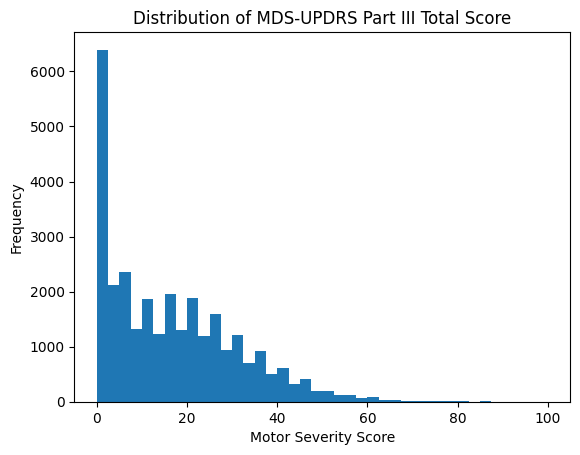

In [23]:
import matplotlib.pyplot as plt

plt.hist(motor['NP3TOT'].dropna(), bins=40)
plt.title("Distribution of MDS-UPDRS Part III Total Score")
plt.xlabel("Motor Severity Score")
plt.ylabel("Frequency")
plt.show()


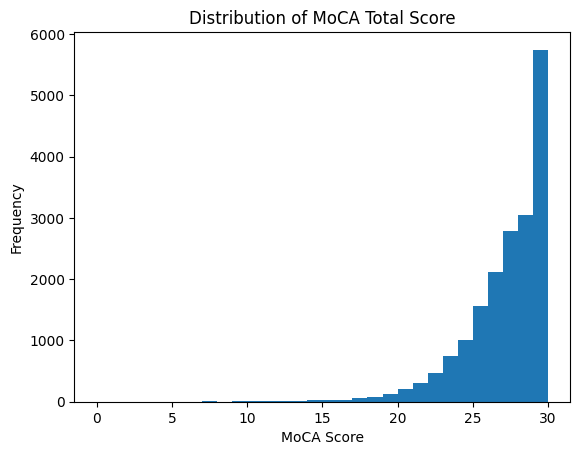

In [24]:
plt.hist(moca['MCATOT'].dropna(), bins=30)
plt.title("Distribution of MoCA Total Score")
plt.xlabel("MoCA Score")
plt.ylabel("Frequency")
plt.show()


In [25]:
merged = motor[['PATNO','EVENT_ID','NP3TOT']].merge(
    moca[['PATNO','EVENT_ID','MCATOT']],
    on=['PATNO','EVENT_ID'],
    how='inner'
)

merged.shape


(21360, 4)

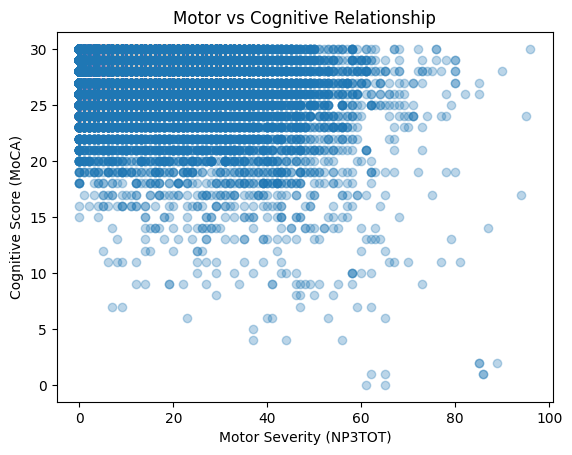

In [26]:
plt.scatter(merged['NP3TOT'], merged['MCATOT'], alpha=0.3)
plt.xlabel("Motor Severity (NP3TOT)")
plt.ylabel("Cognitive Score (MoCA)")
plt.title("Motor vs Cognitive Relationship")
plt.show()


In [27]:
visits_per_patient.describe()


,EVENT_ID
count,4871.000000
mean,6.210018
std,5.848641
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,27.000000
